# 02_ae_v1: AE as a Prior compressor (Bousquet-style probe)

**Framing.** The autoencoder is a **compressor of the LOVECLIM Prior**, not
a predictor of held-out events. It is fit and evaluated on all
804 ages, per the setup of Bousquet 2025 §3.1.

## Contents

1) **POD baseline.** Fit POD on the 804 LOVECLIM Prior snapshots. Record
   $E_d$ and °C-RMSE at each $k$ in `LATENT_DIMS`, the linear reference
   any AE must beat.
2) **AE latent-dim sweep.** Train `ConvAE(d)` for every $d$ in
   `LATENT_DIMS`, compute in-sample $E_d$ and °C-RMSE, plot AE vs POD
   across $d$.
3) **5-artefact eval at the focus dim ($d=16$).** Loss curves;
   reconstruction grid across five D-O states; per-cell °C-RMSE map;
   reconstruction error distribution.
4) **Layer-2 deep dive at $d=2$.** Train a fresh $d=2$ AE with per-epoch
   state snapshots, then: per-mode learning accuracy $e_k$ vs epoch; 2D
   latent scatter coloured by D-O event and by age; sign-of-$Z_2$ and
   K-means partitions of the latent; per-cluster distributions of the
   top-5 POD coefficients; per-cluster mean physical-space fields in
   °C anomaly.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from paleoreco.data import (
    build_prior_cube, compute_zscore_stats, apply_zscore, PaleoFieldDataset,
)
from paleoreco.splits import assign_event_label
from paleoreco.models.autoencoder import ConvAE, count_parameters
from paleoreco import train_ae
from paleoreco.train_ae import set_seed
from paleoreco.eval import (
    # Layer 1
    plot_loss_curves,
    plot_reconstructions,
    per_cell_rmse_celsius, plot_per_cell_rmse,
    plot_recon_distribution,
    pod_fit, pod_predict, compute_E_d,
    plot_latent_sweep,
    reconstruct_split,
    # Layer 2
    compute_pod_time_coefficients,
    per_mode_learning_accuracy,
    plot_per_mode_learning_curves,
    plot_latent_2d,
    partition_latent_2d,
    plot_per_cluster_pod_distributions,
    plot_per_cluster_reconstructions,
)

plt.rcParams["figure.dpi"] = 110


/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Hyperparameters --------------------------------------------------------
# Bousquet-style in-sample setup. No val loader, no early stopping, fixed
# epoch count. Sweep range follows Bousquet's parametric study. D_FOCUS
# fixes the dimension for the focus-dim diagnostics; D_DEEP = 2 is
# Bousquet's direct-visualisation choice for the latent-space analysis.
LATENT_DIMS  = [2, 4, 8, 16, 32, 64]
D_FOCUS      = 16
D_DEEP       = 2
BATCH_SIZE   = 32
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 200
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
SEED         = 0

CKPT_DIR = "../outputs/checkpoints"
FIG_DIR  = "../outputs/figures"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

set_seed(SEED)
print(f"Using {DEVICE.upper()}. {len(LATENT_DIMS)} configs x {MAX_EPOCHS} epochs.")

Using CUDA. 6 configs x 200 epochs.


In [3]:
# Build the Prior cube (cached) and the all-ages z-score statistics. The
# AE is fit on every age (no held-out subset), so the z-score stats are
# computed on every age too.
#
# Anchor the data paths to the repo root (one level above this notebook) so
# the notebook works regardless of where Jupyter was launched from.
REPO_ROOT = os.path.abspath("..")
cube_info = build_prior_cube(
    prior_csv=os.path.join(REPO_ROOT, "data/Prior.csv"),
    cache_path=os.path.join(REPO_ROOT, "data/cache/prior_cube.npz"),
)
cube = cube_info["cube"].astype(np.float32)
ages = cube_info["ages"].astype(np.int64)
lats = cube_info["lats"]
lons = cube_info["lons"]
valid = cube_info["valid"]
N_AGES = cube.shape[0]
print(f"Prior cube: {cube.shape}, age range {ages.min()}-{ages.max()} yr BP")

all_idx = np.arange(N_AGES)
stats = compute_zscore_stats(cube, train_age_indices=all_idx, valid=valid)
mask = stats["safe_valid"]
cube_z = apply_zscore(cube, stats).astype(np.float32)
print(f"safe_valid cells: {int(mask.sum())} / {mask.size}; "
      f"median per-cell std mtco={np.median(stats['std'][0][mask]):.3f}, "
      f"mtwa={np.median(stats['std'][1][mask]):.3f} C")

dataset = PaleoFieldDataset(cube_z, mask, all_idx)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
print(f"DataLoader: {len(dataset)} samples, batch_size={BATCH_SIZE}.")


Prior cube: (804, 2, 32, 64), age range 29100-49175 yr BP
safe_valid cells: 2048 / 2048; median per-cell std mtco=0.578, mtwa=0.731 C
DataLoader: 804 samples, batch_size=32.


## 1) POD baseline

Bousquet's linear reference for any AE compressor. Fit once on all 804 ages
at $k_{\max} = \max(\text{LATENT\_DIMS})$, then slice down to each `k` in the
sweep and compute $E_d$. A non-linear AE at the same latent dimension should
match or beat POD at every `k`; if POD wins, the AE is failing to use its
non-linear capacity (or the data is fundamentally linear).

In [4]:
max_k = max(LATENT_DIMS)
pod_basis = pod_fit(cube_z, fit_indices=all_idx, mask=mask, max_k=max_k,
                    random_state=SEED)
print(f"POD basis: V_max {pod_basis['V_max'].shape}, "
      f"mu {pod_basis['mu'].shape}, fit on {len(all_idx)} ages.")

# Compute E_d at every sweep k, plus the C-RMSE secondary diagnostic.
pod_E_d_per_k = []
pod_rmse_C_per_k = []
mask_3d = mask[None, None]
for k in LATENT_DIMS:
    pred = pod_predict(cube_z, all_idx, pod_basis, k=k)
    pod_E_d_per_k.append(compute_E_d(cube_z, pred, mask))
    err_c = (pred - cube_z) * stats["std"][None]
    sq = (err_c ** 2) * mask_3d
    pod_rmse_C_per_k.append(float(np.sqrt(sq.sum() / (cube_z.shape[0] * 2 * mask.sum()))))

print("POD E_d / C-RMSE per k:")
for k, e, r in zip(LATENT_DIMS, pod_E_d_per_k, pod_rmse_C_per_k):
    print(f"  k={k:>3d}   E_d={e:.4f}   rmse={r:.3f} C")


POD basis: V_max (64, 4096), mu (1, 4096), fit on 804 ages.
POD E_d / C-RMSE per k:
  k=  2   E_d=0.6537   rmse=0.670 C
  k=  4   E_d=0.8474   rmse=0.407 C
  k=  8   E_d=0.8880   rmse=0.319 C
  k= 16   E_d=0.9184   rmse=0.264 C
  k= 32   E_d=0.9451   rmse=0.211 C
  k= 64   E_d=0.9663   rmse=0.161 C


## 2) AE latent-dim sweep

For each `d` in `LATENT_DIMS`, train a fresh `ConvAE(latent_dim=d)` for
exactly `MAX_EPOCHS` epochs on all 804 ages and record the in-sample $E_d$
and °C-RMSE. Bousquet-style: no val loader, no early stopping, no
model-selection step.


In [5]:
# Wraps paleoreco.train_ae.train with the Bousquet-style conventions:
#   * val_loader=None, patience=None (no early stopping);
#   * all 804 ages in the train loader;
#   * deterministic seeding so the sweep is reproducible.
# Under the val-less mode `out["best_state_dict"]` is the final-epoch
# state; loading it into the returned model lets callers run forward
# without re-loading the checkpoint.
def train_one_config(latent_dim, *, max_epochs=MAX_EPOCHS, seed=SEED,
                     epoch_callback=None, checkpoint_path=None,
                     verbose=False, progress=True):
    set_seed(seed)
    model = ConvAE(latent_dim=latent_dim)
    out = train_ae.train(
        model, loader, None, mask,
        zscore_std=stats["std"],
        lr=LR, weight_decay=WEIGHT_DECAY,
        max_epochs=max_epochs, patience=None,
        device=DEVICE, checkpoint_path=checkpoint_path,
        seed=seed, verbose=verbose, progress=progress,
        epoch_callback=epoch_callback,
    )
    model.load_state_dict(out["best_state_dict"])
    return {"model": model, "history": out["history"],
            "epochs_trained": out["epochs_trained"], "latent_dim": latent_dim}


In [6]:
sweep_results = {}
for d in LATENT_DIMS:
    ckpt = os.path.join(CKPT_DIR, f"ae_dim{d}.pt")
    print(f"--- training d={d} (params: "
          f"{count_parameters(ConvAE(latent_dim=d)):,}) ---")
    sweep_results[d] = train_one_config(d, checkpoint_path=ckpt)


--- training d=2 (params: 211,572) ---


train(d=2): 100%|██████████| 200/200 [00:23<00:00,  8.34ep/s, train_mse_z=0.0953, s/ep=0.1]


--- training d=4 (params: 227,958) ---


train(d=4): 100%|██████████| 200/200 [00:23<00:00,  8.48ep/s, train_mse_z=0.0818, s/ep=0.1]


--- training d=8 (params: 260,730) ---


...

train(d=16): 100%|██████████| 200/200 [00:23<00:00,  8.45ep/s, train_mse_z=0.0464, s/ep=0.1]


--- training d=32 (params: 457,362) ---


train(d=32): 100%|██████████| 200/200 [00:23<00:00,  8.41ep/s, train_mse_z=0.0329, s/ep=0.1]


--- training d=64 (params: 719,538) ---


train(d=64): 100%|██████████| 200/200 [00:23<00:00,  8.54ep/s, train_mse_z=0.0223, s/ep=0.1]


In [7]:
# For each trained config, compute reconstructions on all 804 ages, then
# the headline E_d plus the C-RMSE secondary metric.
ae_E_d_per_d = []
ae_rmse_C_per_d = []
truths = {}
preds = {}
for d in LATENT_DIMS:
    truth_z, pred_z = reconstruct_split(sweep_results[d]["model"], dataset,
                                        device=DEVICE, batch_size=BATCH_SIZE)
    truths[d] = truth_z
    preds[d] = pred_z
    ae_E_d_per_d.append(compute_E_d(truth_z, pred_z, mask))
    err_c = (pred_z - truth_z) * stats["std"][None]
    sq = (err_c ** 2) * mask_3d
    ae_rmse_C_per_d.append(float(np.sqrt(sq.sum() / (truth_z.shape[0] * 2 * mask.sum()))))


In [8]:
print(f"{'d':>4s}  {'AE E_d':>9s}  {'POD E_d':>9s}  "
      f"{'AE rmse_C':>10s}  {'POD rmse_C':>11s}  {'AE-POD dE_d':>12s}")
print("-" * 70)
for i, d in enumerate(LATENT_DIMS):
    delta = ae_E_d_per_d[i] - pod_E_d_per_k[i]
    print(f"{d:>4d}  {ae_E_d_per_d[i]:>9.4f}  {pod_E_d_per_k[i]:>9.4f}  "
          f"{ae_rmse_C_per_d[i]:>10.3f}  {pod_rmse_C_per_k[i]:>11.3f}  "
          f"{delta:>+12.4f}")

best_d_idx = int(np.argmax(ae_E_d_per_d))
best_d = LATENT_DIMS[best_d_idx]
print(f"\nBest AE: d={best_d}, E_d={ae_E_d_per_d[best_d_idx]:.4f}")


   d     AE E_d    POD E_d   AE rmse_C   POD rmse_C   AE-POD dE_d
----------------------------------------------------------------------
   2     0.8648     0.6537       0.351        0.670       +0.2112
   4     0.8821     0.8474       0.316        0.407       +0.0347
   8     0.9086     0.8880       0.273        0.319       +0.0206
  16     0.9328     0.9184       0.234        0.264       +0.0144
  32     0.9524     0.9451       0.196        0.211       +0.0073
  64     0.9679     0.9663       0.159        0.161       +0.0016

Best AE: d=64, E_d=0.9679


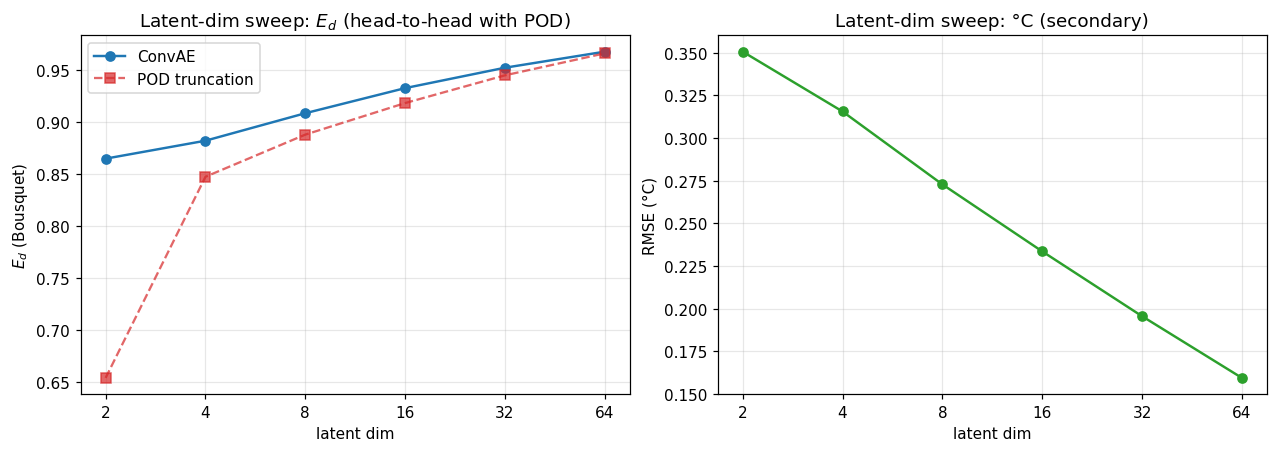

In [9]:
fig = plot_latent_sweep(
    LATENT_DIMS, ae_E_d_per_d,
    pod_E_d=pod_E_d_per_k,
    model_rmse_celsius=ae_rmse_C_per_d,
    model_label="ConvAE",
    save_path=os.path.join(FIG_DIR, "ae_v1_latent_sweep.png"),
)
plt.show()


## 3) 5-artefact eval at the focus dim ($d=16$)

Standard reconstruction diagnostics at the focus configuration
`D_FOCUS=16`:
1. Train / loss curves over `MAX_EPOCHS`.
2. Reconstruction grid for five ages spread across 49–29 ka.
3. Per-cell °C-RMSE map (where the AE errs spatially).
4. Reconstruction error distribution across all 804 ages.

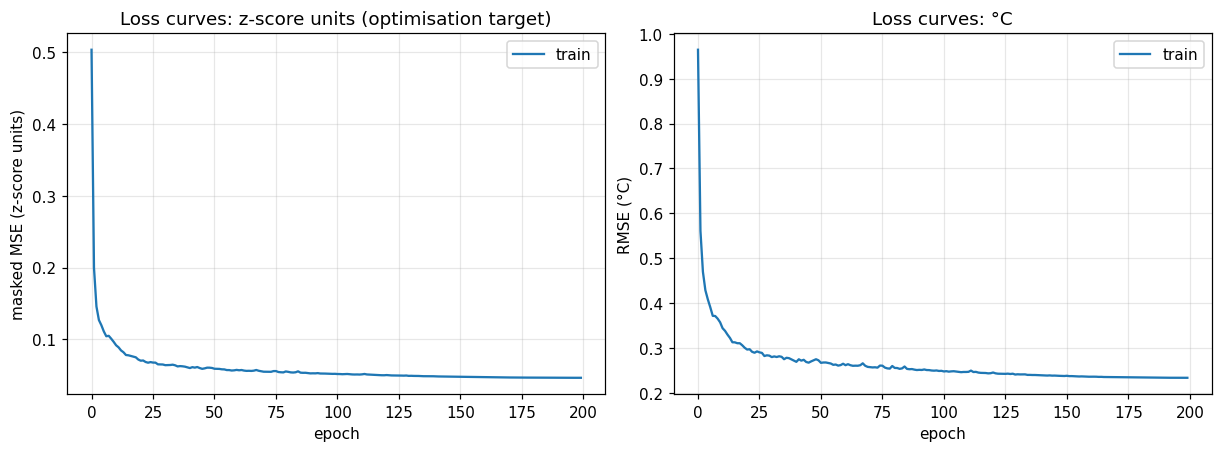

In [10]:
fig = plot_loss_curves(
    sweep_results[D_FOCUS]["history"],
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_FOCUS}_loss.png"),
)
plt.show()


recon sample ages (yr BP): [47000, 42000, 38000, 33000, 30000]


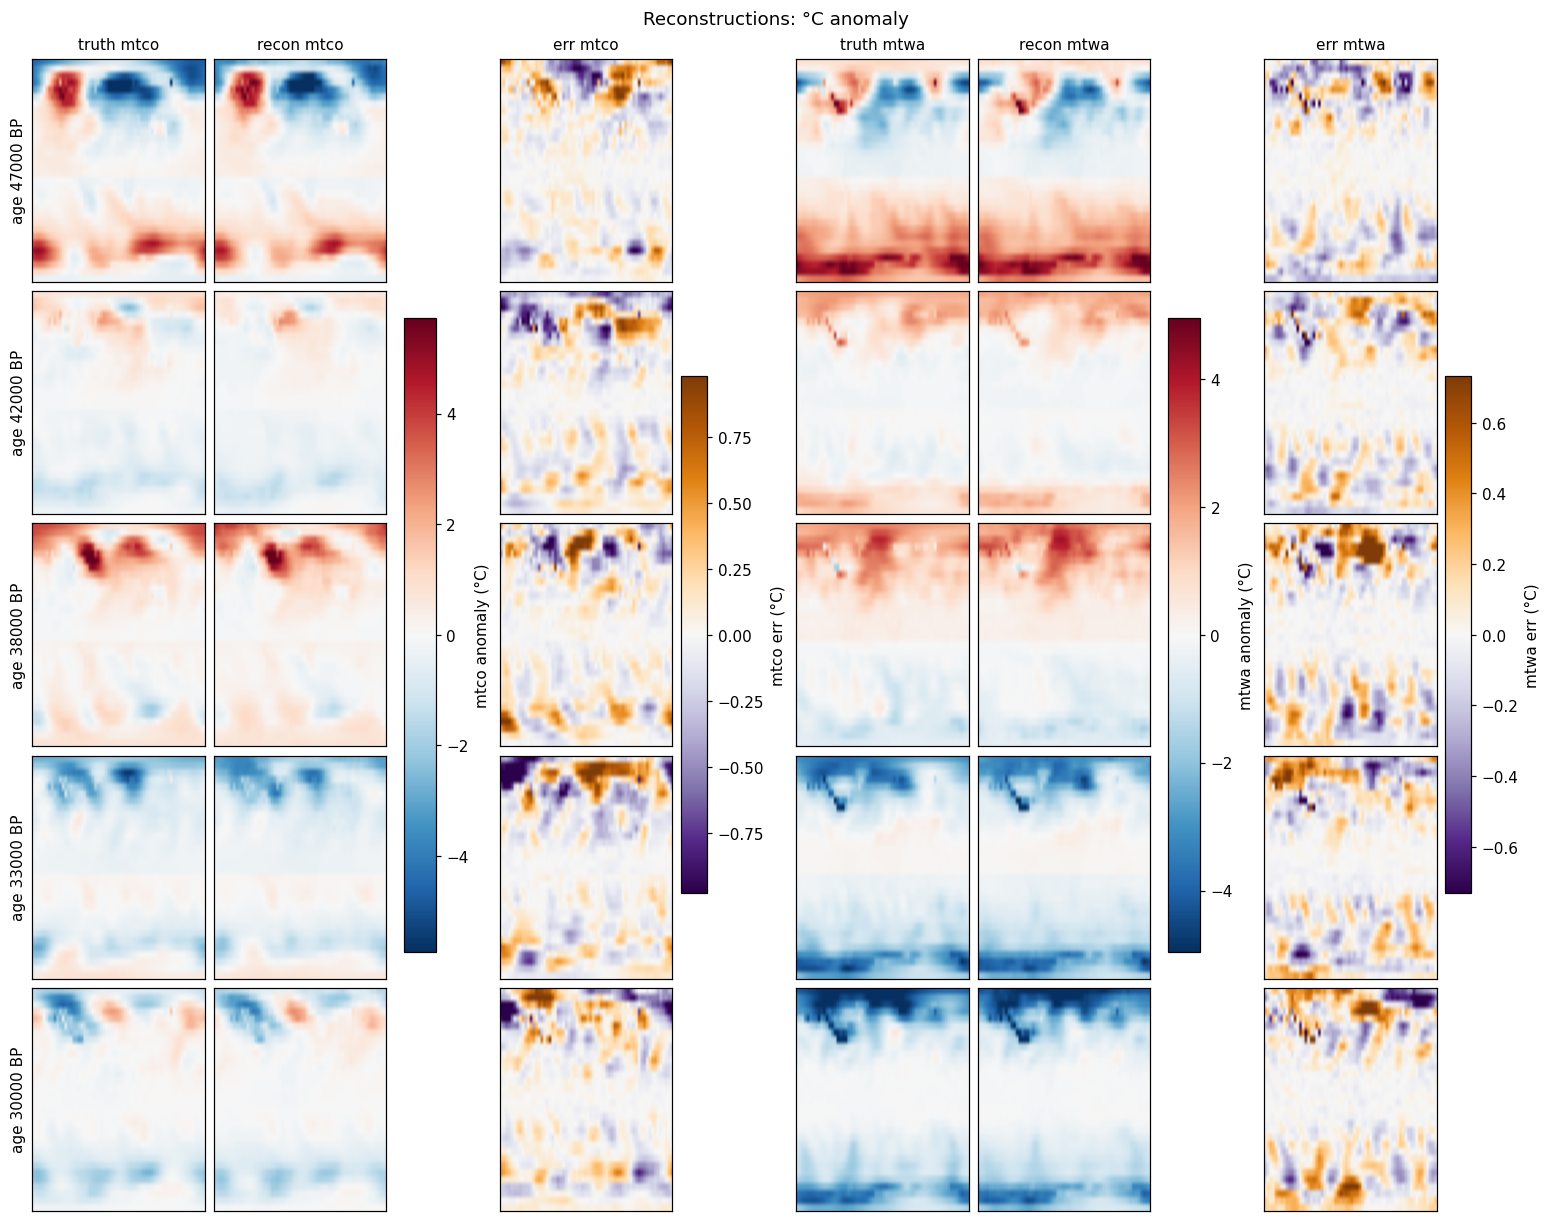

In [11]:
# Pick five ages spread across 49-29 ka so the figure includes both stadial
# and interstadial states across the D-O sequence.
target_ages = [47000, 42000, 38000, 33000, 30000]
sample_idx = [int(np.argmin(np.abs(ages - t))) for t in target_ages]
print("recon sample ages (yr BP):", [int(ages[i]) for i in sample_idx])

fig = plot_reconstructions(
    truths[D_FOCUS], preds[D_FOCUS], stats, ages, lats, lons,
    sample_indices=sample_idx,
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_FOCUS}_recon_grid.png"),
)
plt.show()


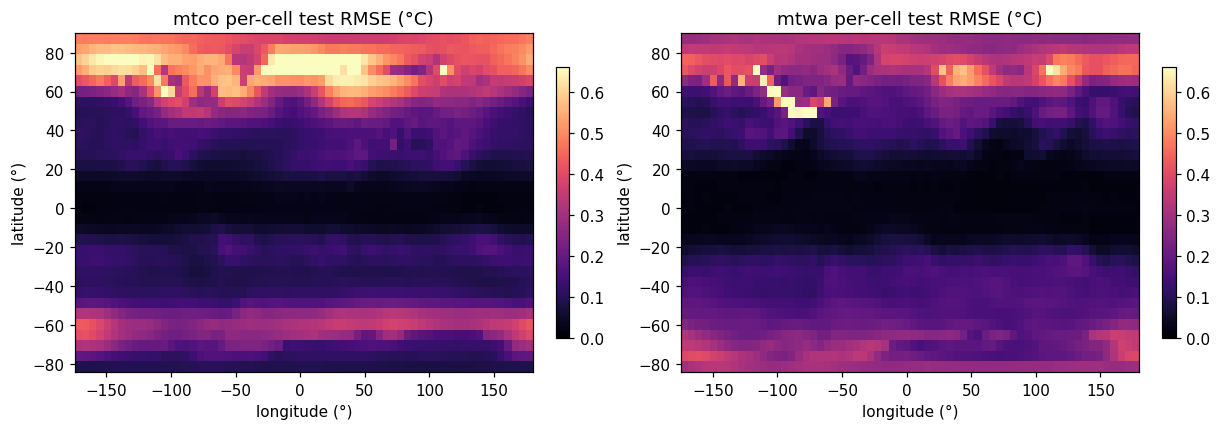

In [12]:
rmse_c = per_cell_rmse_celsius(truths[D_FOCUS], preds[D_FOCUS], stats, mask)
fig = plot_per_cell_rmse(
    rmse_c, lats, lons,
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_FOCUS}_per_cell_rmse.png"),
)
plt.show()


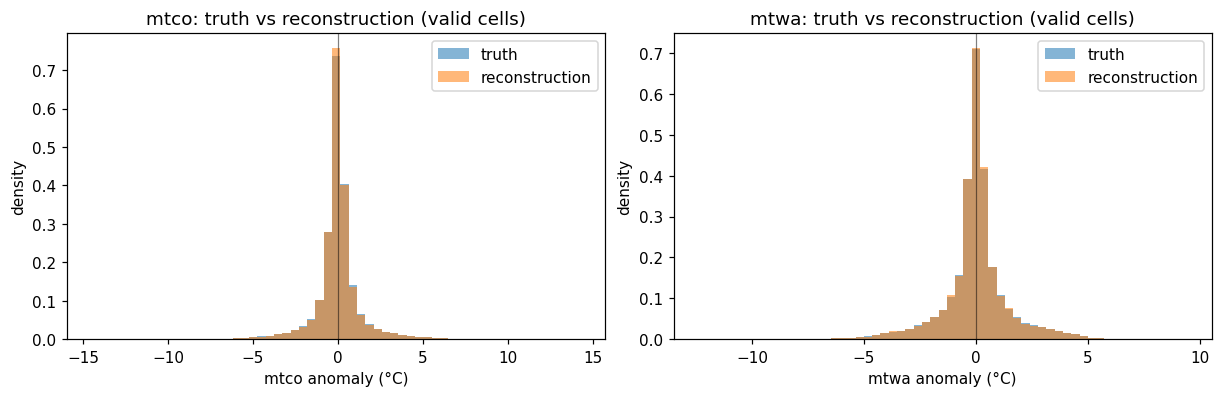

In [13]:
fig = plot_recon_distribution(
    truths[D_FOCUS], preds[D_FOCUS], stats, mask,
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_FOCUS}_recon_distribution.png"),
)
plt.show()


## 4) Layer-2 deep dive at $d=2$

We focus on the 2D latent space. We train a fresh
`ConvAE(latent_dim=2)` while snapshotting the full model state after every
epoch (Bousquet's option (b): re-run forward in post-processing). Then we:

1. Project the truth and per-epoch reconstructions onto the POD basis, and
   compute the per-mode learning accuracy $e_k$ (Eq. 23). Reveals which POD
   modes the AE learns first.
2. Plot the final-epoch latent space coloured by D–O event index.
3. Partition the latent space (sign of $Z_2$ and K-means) and look at the
   per-cluster distributions of the top POD coefficients + the per-cluster
   mean physical-space fields.

In [14]:
# Snapshot the full state dict at the end of every epoch. ConvAE(d=2) is
# ~210k floats -> ~850 kB / epoch * 50 epochs ~= 42 MB, fits easily in RAM.
state_dicts_per_epoch = []

def snapshot_cb(epoch_idx, model):
    state_dicts_per_epoch.append(
        {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    )

deep_result = train_one_config(
    D_DEEP, max_epochs=MAX_EPOCHS, seed=SEED,
    epoch_callback=snapshot_cb,
    checkpoint_path=os.path.join(CKPT_DIR, f"ae_dim{D_DEEP}_deep.pt"),
)
print(f"d={D_DEEP}: snapshots captured = {len(state_dicts_per_epoch)}")


train(d=2): 100%|██████████| 200/200 [00:24<00:00,  8.14ep/s, train_mse_z=0.0948, s/ep=0.1]

d=2: snapshots captured = 200


In [15]:
# Replay each per-epoch state dict to get (a) per-epoch reconstructions and
# (b) per-epoch AE-projected POD time-coefficients. Truth POD coefficients
# come from the POD basis fit earlier on the full cube.
deep_model = ConvAE(latent_dim=D_DEEP)
deep_model.eval()

# Build a single (N_AGES, 3, H, W) input tensor once: cube_z + mask channel.
all_inputs = torch.from_numpy(
    np.concatenate([
        cube_z,
        np.broadcast_to(mask.astype(np.float32)[None, None],
                        (N_AGES, 1, *mask.shape)),
    ], axis=1).astype(np.float32)
)

n_epochs = len(state_dicts_per_epoch)
ae_a_k_per_epoch = np.empty((n_epochs, N_AGES, max_k), dtype=np.float64)
final_latents = None
with torch.no_grad():
    for ep, sd in enumerate(state_dicts_per_epoch):
        deep_model.load_state_dict(sd)
        x_hat, z = deep_model(all_inputs)
        recon = x_hat.cpu().numpy()
        ae_a_k_per_epoch[ep] = compute_pod_time_coefficients(recon, mask, pod_basis)
        if ep == n_epochs - 1:
            final_latents = z.cpu().numpy()

# Truth a_k(t): project cube_z onto the same POD basis.
pod_a_k = compute_pod_time_coefficients(cube_z, mask, pod_basis)
print("pod_a_k:", pod_a_k.shape, "ae_a_k_per_epoch:", ae_a_k_per_epoch.shape,
      "final_latents:", final_latents.shape)


pod_a_k: (804, 64) ae_a_k_per_epoch: (200, 804, 64) final_latents: (804, 2)


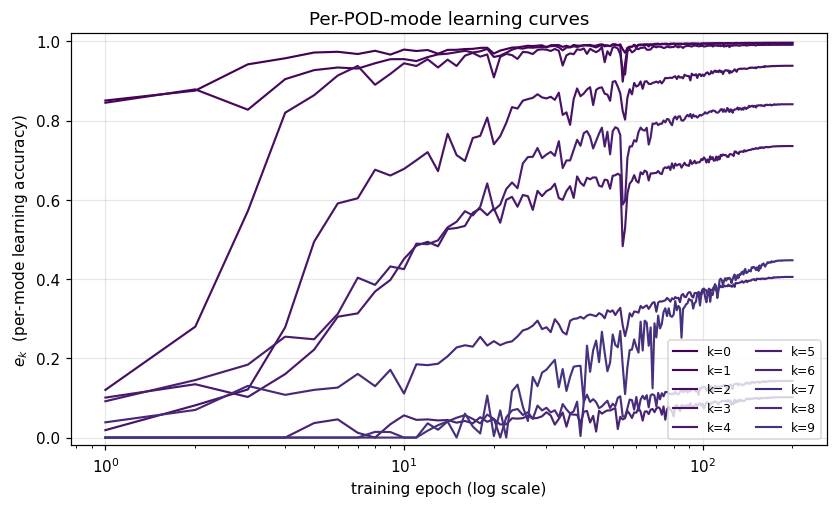

Final-epoch e_k (top 10 POD modes):
  k= 0: e_k = 0.996
  k= 1: e_k = 0.995
  k= 2: e_k = 0.991
  k= 3: e_k = 0.938
  k= 4: e_k = 0.736
  k= 5: e_k = 0.841
  k= 6: e_k = 0.102
  k= 7: e_k = 0.405
  k= 8: e_k = 0.143
  k= 9: e_k = 0.447


In [16]:
e_k = per_mode_learning_accuracy(pod_a_k, ae_a_k_per_epoch)
fig = plot_per_mode_learning_curves(
    e_k, ks_to_show=list(range(min(10, max_k))),
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_per_mode_learning.png"),
)
plt.show()

print("Final-epoch e_k (top 10 POD modes):")
for k in range(min(10, max_k)):
    print(f"  k={k:>2d}: e_k = {e_k[-1, k]:.3f}")


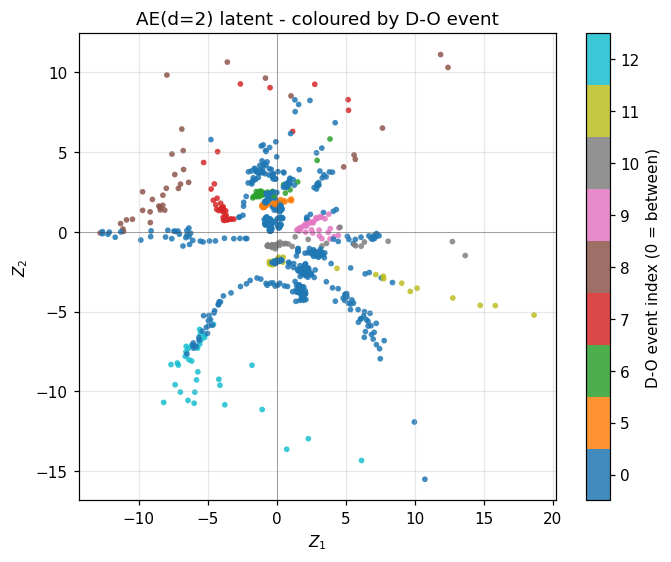

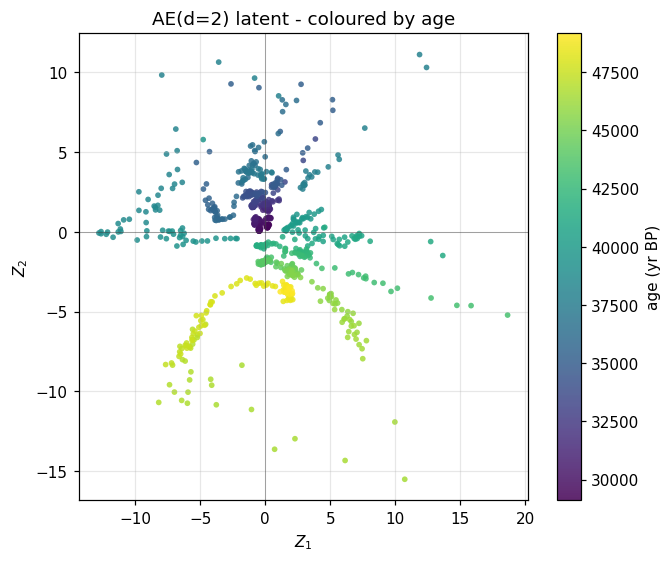

In [17]:
# D-O event label per age (0 = between events); used to colour the latent.
event_labels = assign_event_label(ages)
fig = plot_latent_2d(
    final_latents, event_labels, color_label="D-O event index (0 = between)",
    title=f"AE(d={D_DEEP}) latent - coloured by D-O event",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_latent_by_event.png"),
)
plt.show()

fig = plot_latent_2d(
    final_latents, ages, color_label="age (yr BP)",
    title=f"AE(d={D_DEEP}) latent - coloured by age",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_latent_by_age.png"),
)
plt.show()


z2_sign cluster sizes: [373, 431]
kmeans-4 cluster sizes: [225, 433, 61, 85]


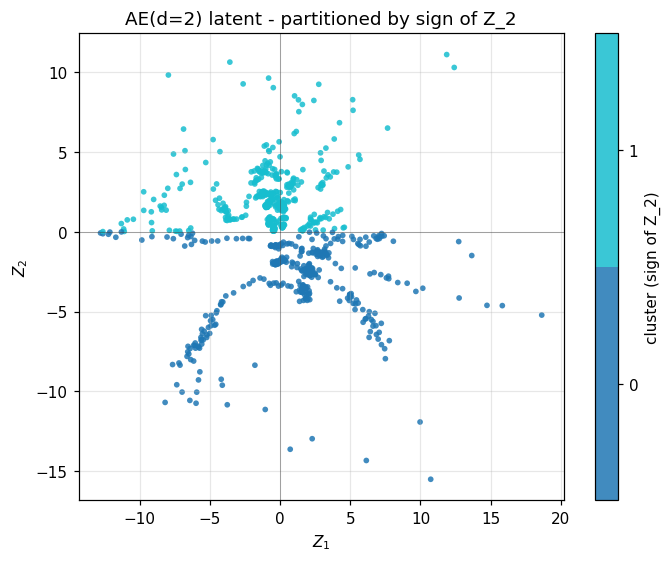

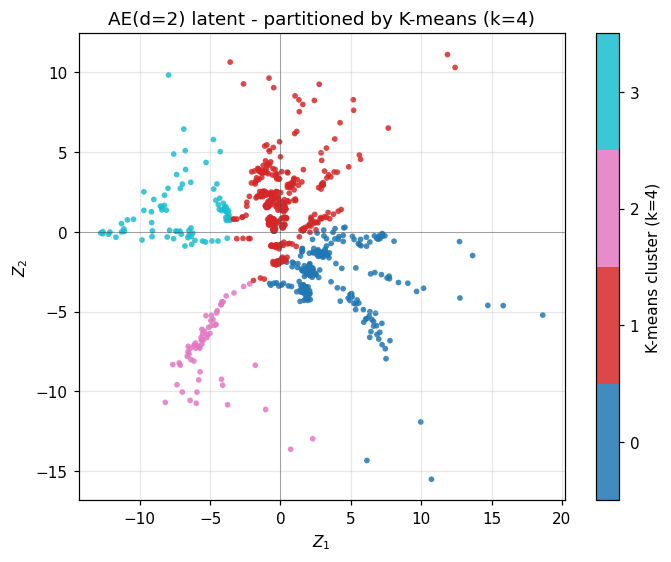

In [18]:
labels_sign = partition_latent_2d(final_latents, "z2_sign")
labels_km4 = partition_latent_2d(final_latents, 4, random_state=SEED)
print(f"z2_sign cluster sizes: "
      f"{[int((labels_sign == c).sum()) for c in np.unique(labels_sign)]}")
print(f"kmeans-4 cluster sizes: "
      f"{[int((labels_km4 == c).sum()) for c in np.unique(labels_km4)]}")

fig = plot_latent_2d(
    final_latents, labels_sign, color_label="cluster (sign of Z_2)",
    title=f"AE(d={D_DEEP}) latent - partitioned by sign of Z_2",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_partition_sign.png"),
)
plt.show()
fig = plot_latent_2d(
    final_latents, labels_km4, color_label="K-means cluster (k=4)",
    title=f"AE(d={D_DEEP}) latent - partitioned by K-means (k=4)",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_partition_kmeans4.png"),
)
plt.show()


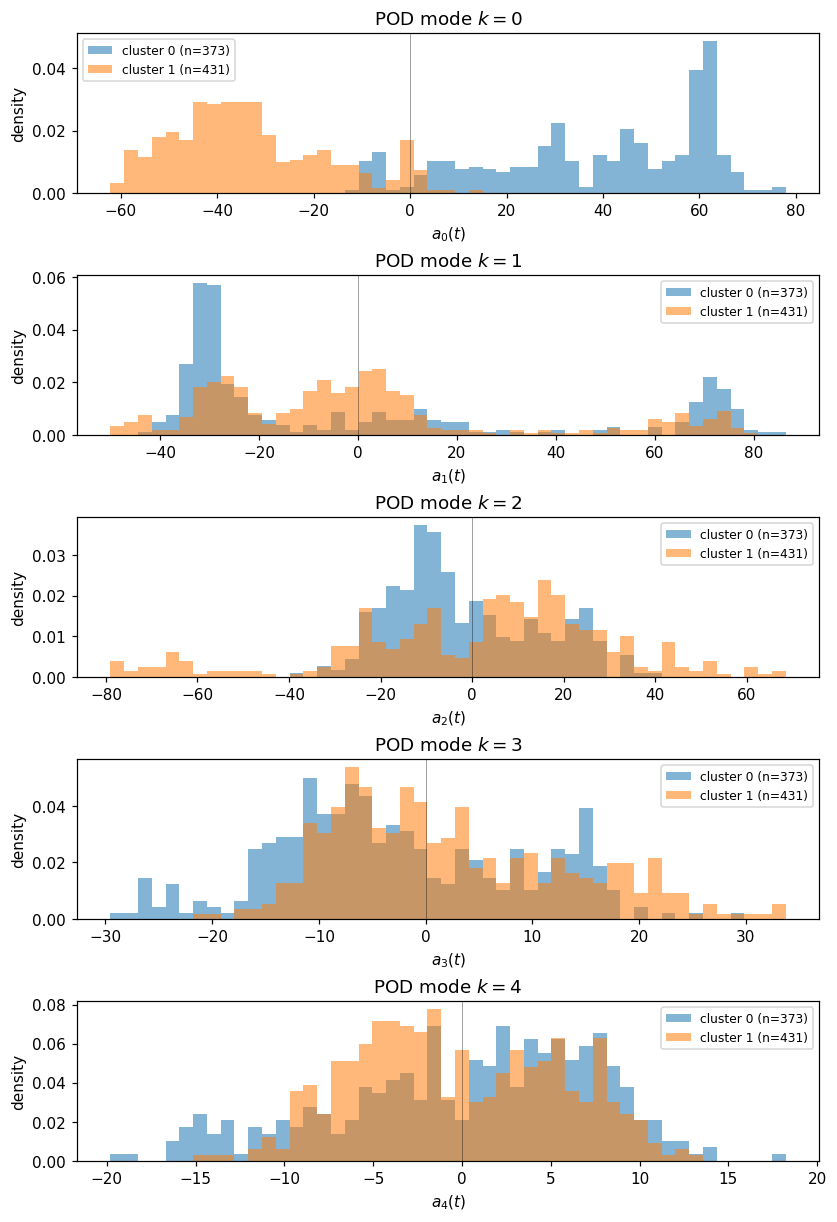

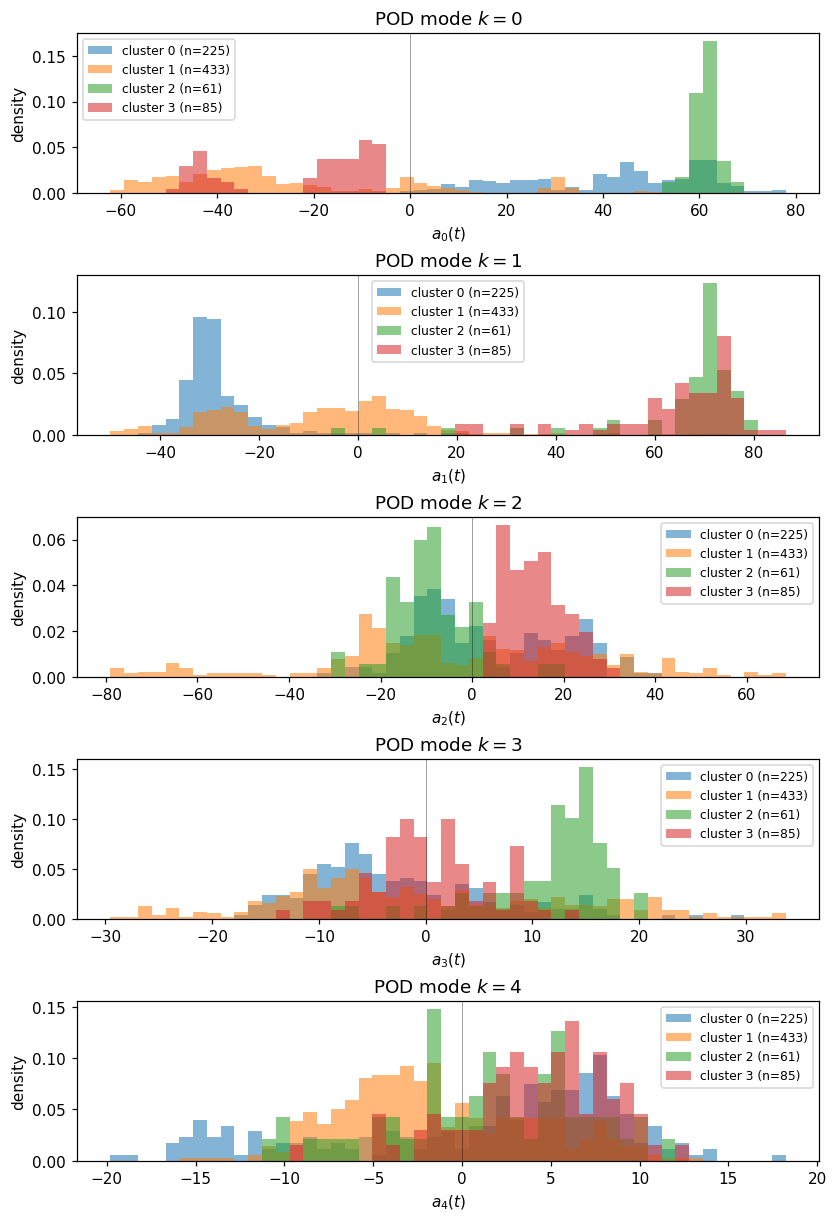

In [19]:
# Top-5 POD modes is the typical Bousquet display (his Fig 15 picks the
# energetic / event-relevant ones); the first 5 modes are the most
# energetic by construction (largest singular values).
TOP_K = list(range(5))
fig = plot_per_cluster_pod_distributions(
    pod_a_k, labels_sign, ks_to_show=TOP_K,
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_pod_dist_sign.png"),
)
plt.show()
fig = plot_per_cluster_pod_distributions(
    pod_a_k, labels_km4, ks_to_show=TOP_K,
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_pod_dist_km4.png"),
)
plt.show()


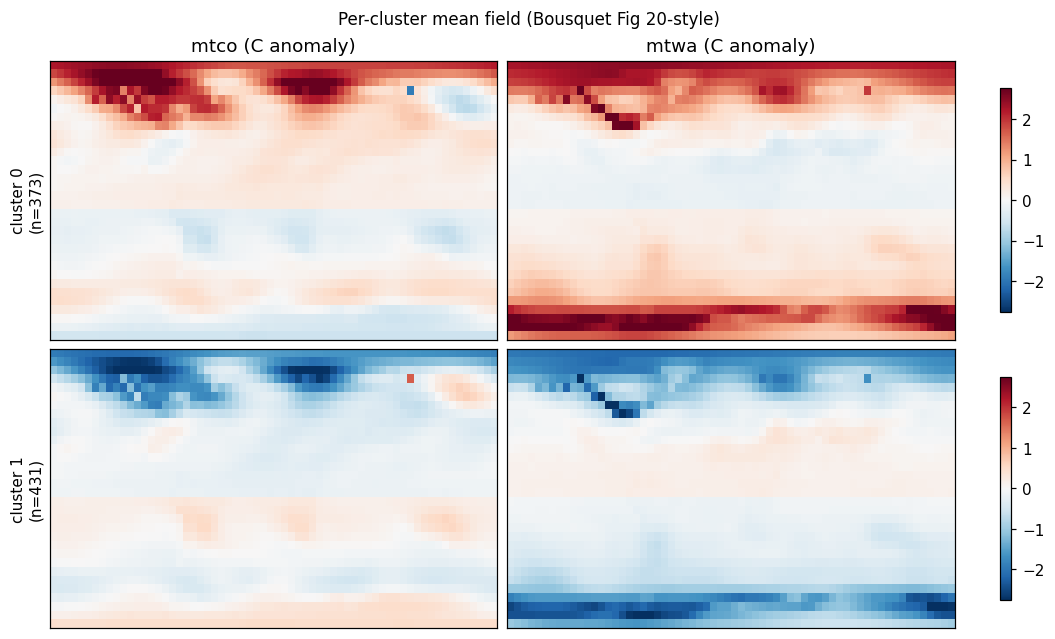

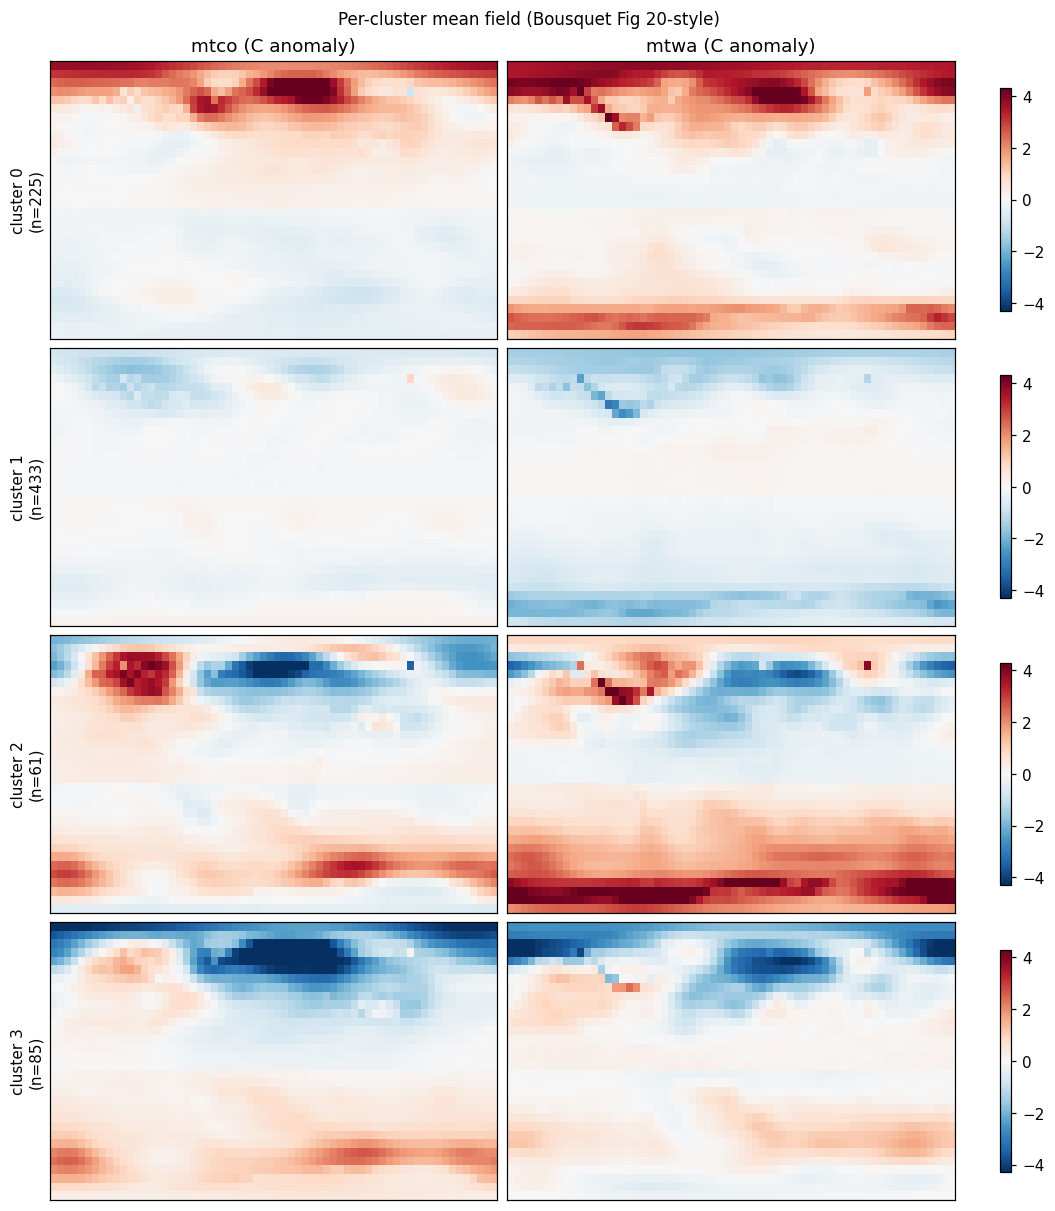

In [20]:
# C anomaly is the climate-readable unit. anomaly = x - mean = z * std, so
# no mean addition is needed when converting z-score back to anomaly.
cube_anomaly = cube_z * stats["std"][None]

fig = plot_per_cluster_reconstructions(
    cube_anomaly, labels_sign, lats, lons, mask,
    var_names=("mtco", "mtwa"), unit_label="C anomaly",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_cluster_recon_sign.png"),
)
plt.show()
fig = plot_per_cluster_reconstructions(
    cube_anomaly, labels_km4, lats, lons, mask,
    var_names=("mtco", "mtwa"), unit_label="C anomaly",
    save_path=os.path.join(FIG_DIR, f"ae_v1_d{D_DEEP}_cluster_recon_km4.png"),
)
plt.show()
